Dataset Loaded Successfully
Dataset Shape: (150, 5)

First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal_length    0
sepal_w

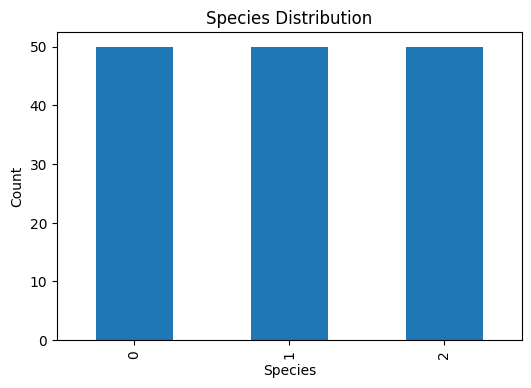

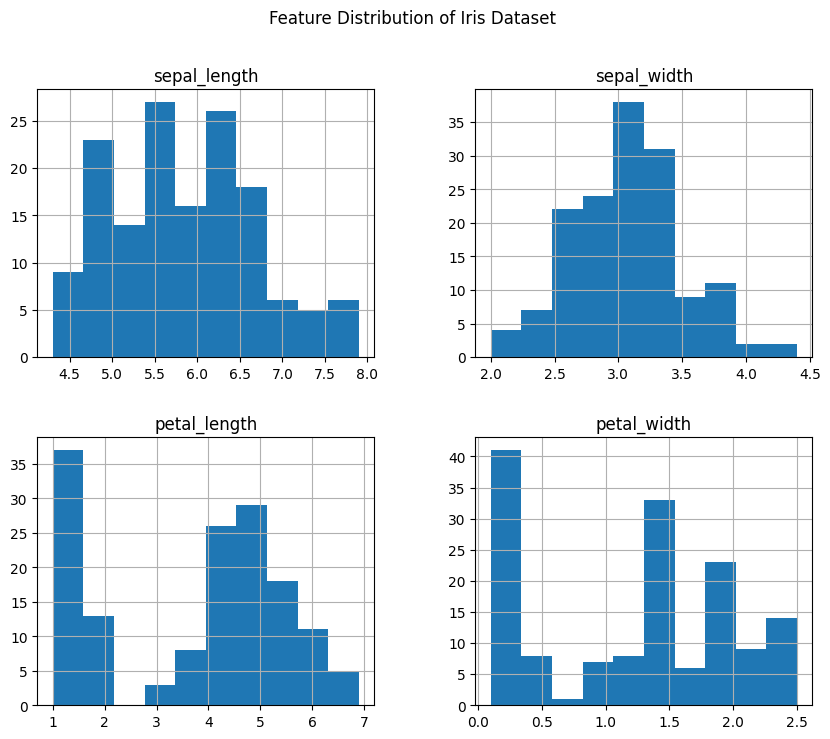

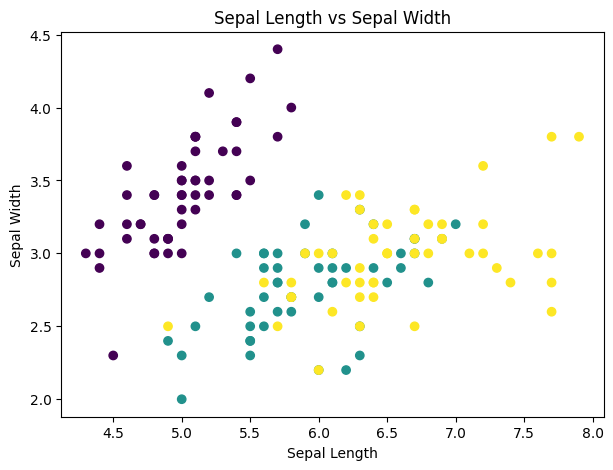

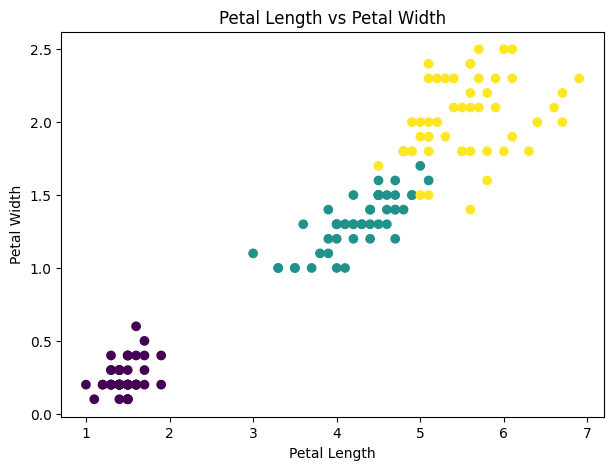

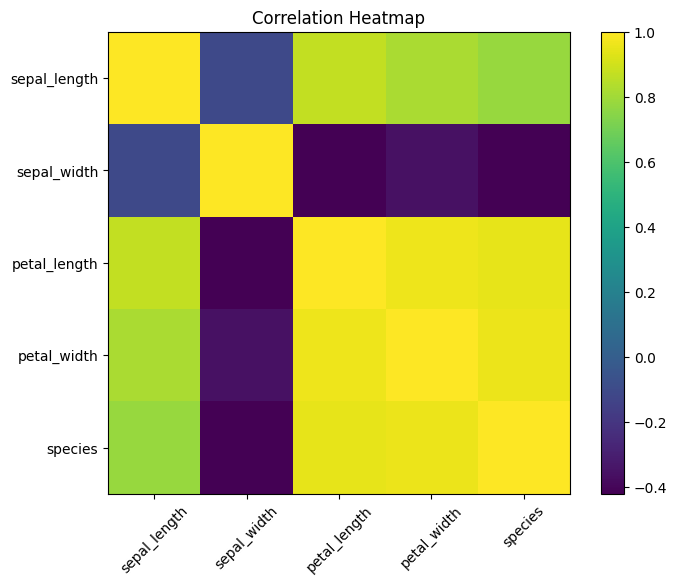


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)

Logistic Regression
Accuracy: 93.33 %
Cross Validation Score: 96.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Decision Tree
Accuracy: 93.33 %
Cross Validation Score: 95.33 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accurac

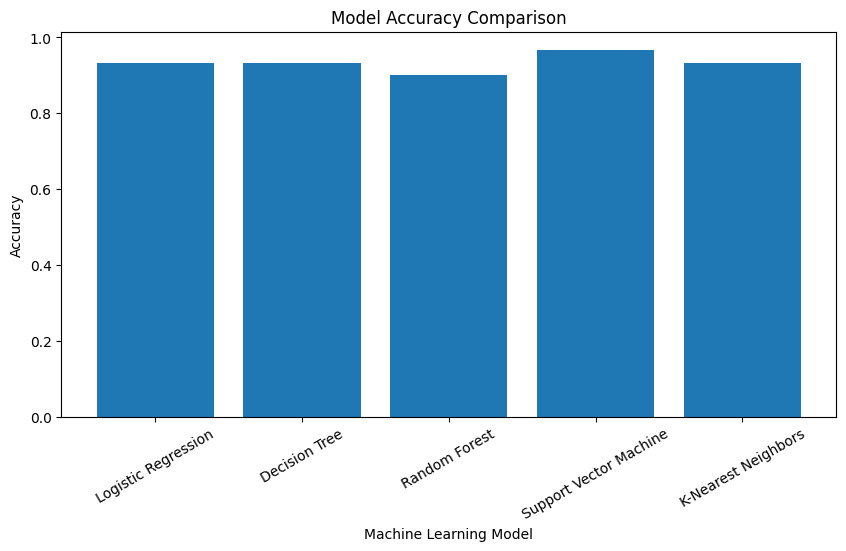

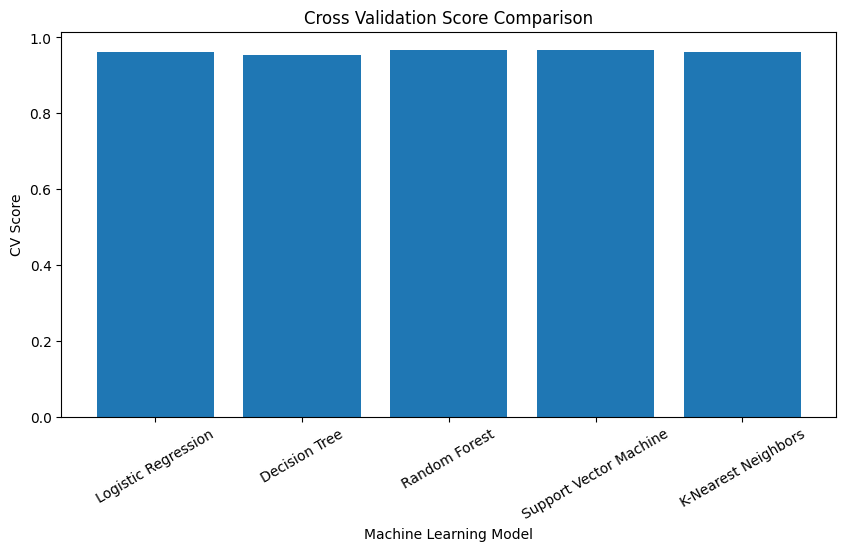


Best Performing Model: Support Vector Machine

Final Model Accuracy: 90.0 %

Feature Importance:
        Feature  Importance
3   petal_width    0.437185
2  petal_length    0.431466
0  sepal_length    0.116349
1   sepal_width    0.015000


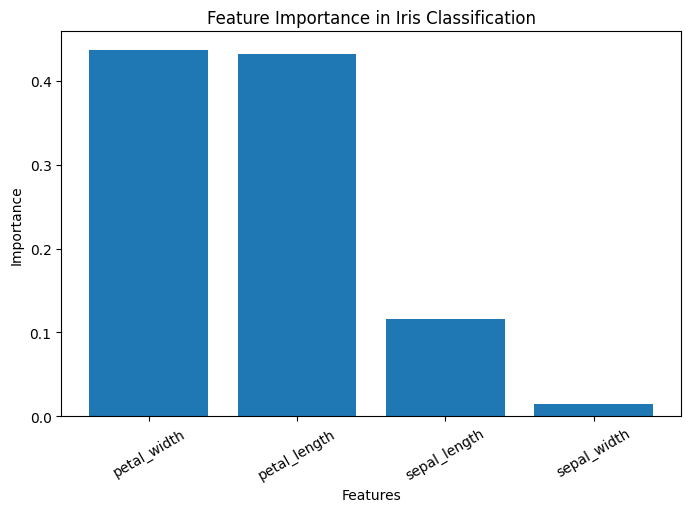


Sample Flower Data:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Iris Species: Iris-setosa


In [3]:
# CODSOFT Data Science Internship
# Task 3: Iris Flower Classification - Professional Version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset
df = pd.read_csv("IRIS.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# 2. Column Check
print("\nColumns:")
print(df.columns)

# 3. Encode Target Column
le = LabelEncoder()
df["species"] = le.fit_transform(df["species"])

print("\nSpecies Encoding:")
for i, name in enumerate(le.classes_):
    print(i, "=", name)

# 4. Species Distribution
plt.figure(figsize=(6,4))
df["species"].value_counts().plot(kind="bar")
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# 5. Feature Distribution
df.drop("species", axis=1).hist(figsize=(10,8))
plt.suptitle("Feature Distribution of Iris Dataset")
plt.show()

# 6. Scatter Plot: Sepal Length vs Sepal Width
plt.figure(figsize=(7,5))
plt.scatter(df["sepal_length"], df["sepal_width"], c=df["species"])
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

# 7. Scatter Plot: Petal Length vs Petal Width
plt.figure(figsize=(7,5))
plt.scatter(df["petal_length"], df["petal_width"], c=df["species"])
plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

# 8. Correlation Heatmap
corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# 9. Features and Target
X = df.drop("species", axis=1)
y = df["species"]

# 10. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# 11. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 12. Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

results = {}
cv_results = {}

for name, model in models.items():

    if name in ["Logistic Regression", "Support Vector Machine", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_score = cross_val_score(model, scaler.fit_transform(X), y, cv=5).mean()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_score = cross_val_score(model, X, y, cv=5).mean()

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    cv_results[name] = cv_score

    print("\n====================================")
    print(name)
    print("====================================")
    print("Accuracy:", round(accuracy * 100, 2), "%")
    print("Cross Validation Score:", round(cv_score * 100, 2), "%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# 13. Model Comparison
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values()),
    "Cross Validation Score": list(cv_results.values())
})

print("\nModel Comparison:")
print(comparison_df)

plt.figure(figsize=(10,5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(comparison_df["Model"], comparison_df["Cross Validation Score"])
plt.title("Cross Validation Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("CV Score")
plt.xticks(rotation=30)
plt.show()

# 14. Best Model Selection
best_model_name = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print("\nBest Performing Model:", best_model_name)

# 15. Final Model
final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("\nFinal Model Accuracy:", round(accuracy_score(y_test, final_pred) * 100, 2), "%")

# 16. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance in Iris Classification")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.show()

# 17. Real Sample Prediction
sample_flower = pd.DataFrame({
    "sepal_length": [5.1],
    "sepal_width": [3.5],
    "petal_length": [1.4],
    "petal_width": [0.2]
})

sample_prediction = final_model.predict(sample_flower)
predicted_species = le.inverse_transform(sample_prediction)

print("\nSample Flower Data:")
print(sample_flower)

print("\nPredicted Iris Species:", predicted_species[0])